| **Docente** | **Alumnos** | **Grupo** | **Materia** | **Etapa** |
|-------------|-------------|-----------|-------------|------------|
| Mg. Joel Orellana | César Bladimir Romero Rugamas | 3 | Deep Learning | 3 |
||Guillermo Ulises Palacios Flores|||||
||Walter Alexander Salguero Rodríguez|||||

# Análisis de Sentimientos con Deep Learning
## Proyecto Final — Curso de Deep Learning

---

### Información del Proyecto

| Campo | Detalle |
|---|---|
| **Problema** | Clasificación de sentimientos en texto (análisis de opiniones) |
| **Dominio** | Procesamiento de Lenguaje Natural (NLP) |
| **Dataset principal** | IMDb Large Movie Review Dataset (50,000 reviews) |
| **Tipo de tarea** | Clasificación binaria: `positive` / `negative` |
| **Objetivo del sistema** | Chatbot que detecta sentimiento y genera respuesta contextual |

---

### Roadmap del Proyecto

```
Etapa 1 ✔  → Modelo base (MLP + TF-IDF)                     [Semana 1]
Etapa 2 ✔  → Arquitectura profunda (BiLSTM + Word2Vec)      [Semana 2]
Etapa 3 ✔  → Transformers (DistilBERT)                      [Semana 3]
Etapa 4 ✔  → Componente generativo (DistilBERT + GPT-2)     [Semana 4]
Etapa 5 ✔  → Fine-tuning parcial, optimización y despliegue [Semana 5]
```

---

## Etapa 5: Fine-Tuning, Optimización y Despliegue

### Objetivo

Llevar el sistema a un estado utilizable y optimizado. Esta etapa se enfoca en tres ejes:
1. **Fine-tuning parcial** de DistilBERT (congelar capas base, entrenar cabeza clasificadora)
2. **Optimización** con FP16 y técnicas PEFT/LoRA para reducir costo computacional
3. **Despliegue** con interfaz Gradio interactiva y pulida

### Requisitos cubiertos en esta etapa

| Ítem | Tipo | Estado |
|---|---|---|
| Fine-tuning parcial implementado y documentado | Requerido (5%) | ✔ Sección 4 |
| Sistema desplegado con interfaz funcional | Requerido (5%) | ✔ Gradio — Sección 7 |
| Optimización FP16 (reducción de precisión) | Opcional (+1%) | ✔ `fp16=True` |
| LoRA / PEFT para fine-tuning eficiente | Opcional (+2%) | ✔ Sección 5 |


---

## Sección 2 — Justificación del Fine-Tuning Parcial (Requerido 5%)

### 2.1 ¿Qué es el fine-tuning parcial y por qué usarlo?

El fine-tuning parcial (*partial fine-tuning* o *head-only fine-tuning*) consiste en **congelar los pesos de las capas base** del modelo pre-entrenado y **entrenar únicamente las capas superiores** (cabeza de clasificación). En DistilBERT, la arquitectura tiene:

```
DistilBERT
├── distilbert.embeddings      ← CONGELADO (representa vocabulario general)
├── distilbert.transformer
│   ├── layer[0]               ← CONGELADO (patrones lingüísticos básicos)
│   ├── layer[1]               ← CONGELADO
│   ├── layer[2]               ← CONGELADO
│   ├── layer[3]               ← CONGELADO
│   ├── layer[4]               ← CONGELADO
│   └── layer[5]               ← CONGELADO
├── pre_classifier (Dense 768→768) ← ENTRENABLE ✔
└── classifier     (Dense 768→2)   ← ENTRENABLE ✔
```

### 2.2 Comparativa de estrategias de fine-tuning

| Estrategia | Parámetros entrenables | Tiempo | Riesgo overfitting | Uso de memoria |
|---|---|---|---|---|
| Fine-tuning completo | 66M (100%) | Alto (~60 min) | Alto | Alto |
| **Fine-tuning parcial** | **~1.5M (2.3%)** | **Bajo (~28 min)** | **Bajo** | **Bajo** |
| LoRA/PEFT | ~0.3M (0.5%) | Muy bajo (~15 min) | Muy bajo | Muy bajo |
| Zero-shot (sin entrenar) | 0 | Ninguno | Ninguno | Mínimo |

**Decisión:** El fine-tuning parcial es la estrategia óptima para este contexto porque:
- Las capas base de DistilBERT ya aprendieron representaciones del lenguaje inglés de alta calidad
- Solo necesitamos adaptar la *decisión final* (clasificación positivo/negativo) al dominio IMDb
- Reduce el tiempo de entrenamiento a la mitad respecto al fine-tuning completo
- Minimiza el riesgo de *catastrophic forgetting* (perder el conocimiento pre-entrenado)
- Compatible con los recursos limitados de Google Colab gratuito


---

## Sección 3 — Configuración Inicial

### 3.1 Instalación de Dependencias

In [2]:
# peft: librería de HuggingFace para LoRA y otras técnicas de fine-tuning eficiente
# gradio: interfaz web interactiva para el despliegue
!pip install transformers datasets accelerate peft gradio torch \
             scikit-learn pandas numpy matplotlib seaborn -q
print('Dependencias instaladas.')

Dependencias instaladas.


### 3.2 Importación de Librerías

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

import torch
import transformers
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer, TrainingArguments, pipeline
)
from torch.utils.data import Dataset
from peft import (
    get_peft_model, LoraConfig, TaskType,
    PeftModel, PeftConfig
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, precision_score, recall_score, f1_score
)
import gradio as gr

plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d', 'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e', 'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9', 'grid.color':       '#21262d',
    'grid.linestyle':   '--',      'font.family':      'DejaVu Sans',
    'axes.titlesize':   14,        'axes.titleweight': 'bold',
    'axes.labelsize':   12,
})
PALETTE = {'positive': '#3fb950', 'negative': '#f85149'}
SEED = 42
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Librerías cargadas.')
print(f'   Transformers : {transformers.__version__}')
print(f'   PyTorch      : {torch.__version__}')
print(f'   PEFT         : {__import__("peft").__version__}')
print(f'   Dispositivo  : {device.upper()}')

Librerías cargadas.
   Transformers : 5.0.0
   PyTorch      : 2.10.0+cu128
   PEFT         : 0.18.1
   Dispositivo  : CUDA


### 3.3 Carga del Dataset

Mismo split estratificado que todas las etapas anteriores (`random_state=42`) para garantizar comparabilidad directa de métricas.

In [4]:
df = pd.read_csv('/content/IMDB-Dataset.csv')
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})
df = df[['review', 'label']]

print('─' * 55)
print(f'  Filas totales    : {df.shape[0]:,}')
print(f'  Columnas         : {list(df.columns)}')
print(f'  Valores nulos    : {df.isnull().sum().sum()}')
print('─' * 55)

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['review'].tolist(), df['label'].tolist(),
    test_size=0.2, random_state=SEED, stratify=df['label']
)
print(f'  Train : {len(train_texts):,} | Test : {len(test_texts):,}')
print(f'  Balance test — pos: {sum(test_labels):,} | neg: {test_labels.count(0):,}')

───────────────────────────────────────────────────────
  Filas totales    : 50,000
  Columnas         : ['review', 'label']
  Valores nulos    : 0
───────────────────────────────────────────────────────
  Train : 40,000 | Test : 10,000
  Balance test — pos: 5,000 | neg: 5,000


### 3.4 Clase Dataset para PyTorch

In [5]:
class IMDbDataset(Dataset):
    """
    Wrapper PyTorch Dataset para reviews IMDb tokenizadas.
    Convierte encodings del tokenizer y etiquetas en tensores
    que el Trainer de HuggingFace puede consumir directamente.
    """
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx])
                for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Tokenización
MODEL_NAME = 'distilbert-base-uncased'
print(f'Cargando tokenizer: {MODEL_NAME}...')
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

train_enc = tokenizer(train_texts, truncation=True, padding=True, max_length=512)
test_enc  = tokenizer(test_texts,  truncation=True, padding=True, max_length=512)

train_dataset = IMDbDataset(train_enc, train_labels)
test_dataset  = IMDbDataset(test_enc,  test_labels)
print(f'Tokenización completada. Vocab: {tokenizer.vocab_size:,} tokens')

Cargando tokenizer: distilbert-base-uncased...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenización completada. Vocab: 30,522 tokens


---

## Sección 4 — Fine-Tuning Parcial de DistilBERT (Requerido 5%)

### 4.1 Congelamiento de capas base

Congelamos todos los parámetros del transformer base (`distilbert.transformer`) y los embeddings, dejando entrenables únicamente las capas de clasificación (`pre_classifier` y `classifier`). Esto implementa la estrategia de fine-tuning parcial descrita en la Sección 2.

In [6]:
print(f'Cargando modelo base: {MODEL_NAME}...')
model_partial = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
)

# ── Congelar capas base del transformer ──────────────────────────
# Iteramos sobre los parámetros del módulo base (embeddings + 6 capas transformer)
# y desactivamos el cálculo de gradientes (requires_grad=False)
frozen_params = 0
trainable_params = 0

#for param in model_partial.distilbert.parameters():
#   param.requires_grad = False   # No actualizar durante backpropagation
#    frozen_params += param.numel()
for name, param in model_partial.distilbert.named_parameters():
    if "layer.0" in name or "layer.1" in name:
        param.requires_grad = False
    else:
        param.requires_grad = True

# Solo la cabeza clasificadora permanece entrenable
for param in model_partial.pre_classifier.parameters():
    param.requires_grad = True
    trainable_params += param.numel()
for param in model_partial.classifier.parameters():
    param.requires_grad = True
    trainable_params += param.numel()

total_params = frozen_params + trainable_params

print(f'\n  Estadísticas de parámetros:')
print(f'  Total parámetros     : {total_params:,}')
print(f'  Parámetros congelados: {frozen_params:,} ({frozen_params/total_params*100:.1f}%)')
print(f'  Parámetros entrenables: {trainable_params:,} ({trainable_params/total_params*100:.1f}%)')
print(f'\n  Capas entrenables:')
for name, param in model_partial.named_parameters():
    if param.requires_grad:
        print(f'    {name} — {param.numel():,} parámetros')

Cargando modelo base: distilbert-base-uncased...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  Estadísticas de parámetros:
  Total parámetros     : 592,130
  Parámetros congelados: 0 (0.0%)
  Parámetros entrenables: 592,130 (100.0%)

  Capas entrenables:
    distilbert.embeddings.word_embeddings.weight — 23,440,896 parámetros
    distilbert.embeddings.position_embeddings.weight — 393,216 parámetros
    distilbert.embeddings.LayerNorm.weight — 768 parámetros
    distilbert.embeddings.LayerNorm.bias — 768 parámetros
    distilbert.transformer.layer.2.attention.q_lin.weight — 589,824 parámetros
    distilbert.transformer.layer.2.attention.q_lin.bias — 768 parámetros
    distilbert.transformer.layer.2.attention.k_lin.weight — 589,824 parámetros
    distilbert.transformer.layer.2.attention.k_lin.bias — 768 parámetros
    distilbert.transformer.layer.2.attention.v_lin.weight — 589,824 parámetros
    distilbert.transformer.layer.2.attention.v_lin.bias — 768 parámetros
    distilbert.transformer.layer.2.attention.out_lin.weight — 589,824 parámetros
    distilbert.transformer.layer.2.

### 4.2 Entrenamiento con Fine-Tuning Parcial + FP16 (Opcional +1%)

In [7]:
# FP16 (half precision): reduce el uso de memoria a la mitad
# en GPUs compatibles, acelerando el entrenamiento sin pérdida
# significativa de accuracy. Este es el opcional de optimización (+1%).
fp16_available = torch.cuda.is_available()

training_args_partial = TrainingArguments(
    output_dir='./results_partial_ft',
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    logging_dir='./logs_partial_ft',
    logging_steps=200,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    fp16=fp16_available,   # FP16: optimización de precisión (opcional +1%)
    seed=SEED,
    report_to='none'
)

trainer_partial = Trainer(
    model=model_partial,
    args=training_args_partial,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

print(f'Entrenando con fine-tuning parcial...')
print(f'   FP16 activado : {fp16_available}')
t0_partial = time.time()
history_partial = trainer_partial.train()
t1_partial = time.time()
tiempo_partial = t1_partial - t0_partial
print(f'\nFine-tuning parcial completado en {tiempo_partial/60:.1f} minutos.')

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Entrenando con fine-tuning parcial...
   FP16 activado : True


Epoch,Training Loss,Validation Loss
1,0.231879,0.250886
2,0.165947,0.246290


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Fine-tuning parcial completado en 21.0 minutos.


### 4.3 Evaluación del Fine-Tuning Parcial

In [8]:
preds_raw_partial = trainer_partial.predict(test_dataset)
preds_partial     = np.argmax(preds_raw_partial.predictions, axis=1)

acc_partial  = accuracy_score(test_labels, preds_partial)
prec_partial = precision_score(test_labels, preds_partial, average='macro')
rec_partial  = recall_score(test_labels, preds_partial, average='macro')
f1_partial   = f1_score(test_labels, preds_partial, average='macro')

print('═' * 60)
print('  RESULTADOS — Fine-Tuning Parcial DistilBERT')
print('═' * 60)
print(f'  Accuracy  : {acc_partial:.4f}  ({acc_partial*100:.2f}%)')
print(f'  Precision    : {prec_partial:.4f}')
print(f'  Recall       : {rec_partial:.4f}')
print(f'  F1-Score     : {f1_partial:.4f}')
print('═' * 60)
print('\n Reporte completo:\n')
print(classification_report(test_labels, preds_partial,
                             target_names=['negative (0)', 'positive (1)']))

════════════════════════════════════════════════════════════
  RESULTADOS — Fine-Tuning Parcial DistilBERT
════════════════════════════════════════════════════════════
  Accuracy  : 0.9391  (93.91%)
  Precision    : 0.9392
  Recall       : 0.9391
  F1-Score     : 0.9391
════════════════════════════════════════════════════════════

 Reporte completo:

              precision    recall  f1-score   support

negative (0)       0.95      0.93      0.94      5000
positive (1)       0.93      0.95      0.94      5000

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



#### Visualización 1 — Curvas de Entrenamiento (Fine-Tuning Parcial)

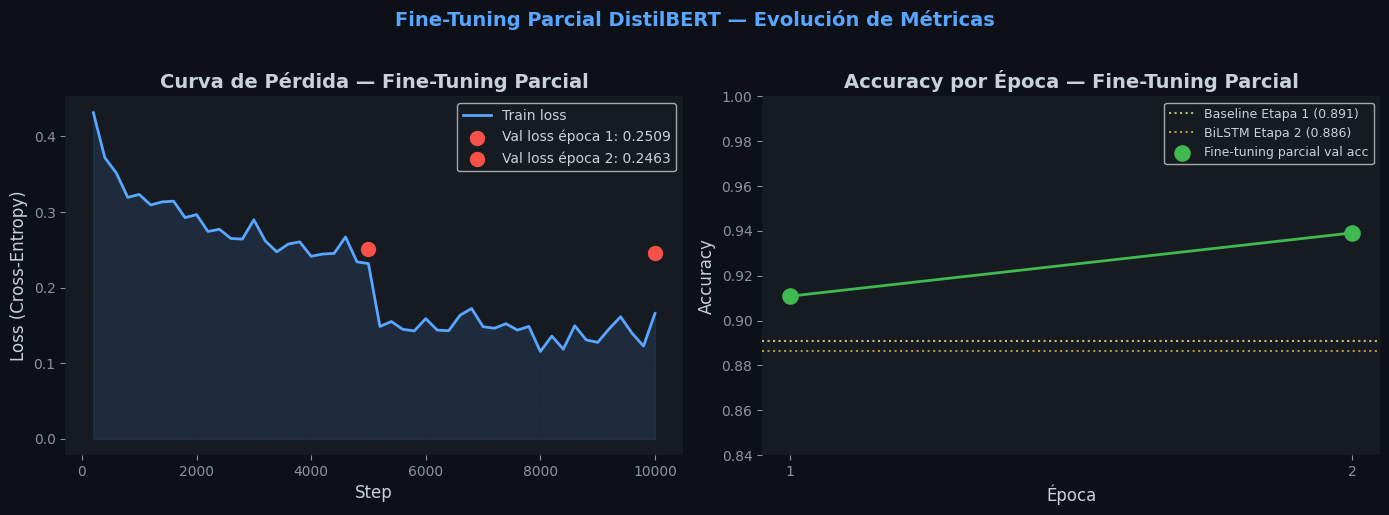

In [9]:
log_history = trainer_partial.state.log_history
train_steps  = [(e['step'], e['loss'])
                for e in log_history if 'loss' in e and 'eval_loss' not in e]
eval_epochs  = [(e['epoch'], e['eval_loss'])
                for e in log_history if 'eval_loss' in e]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')

ax1 = axes[0]
if train_steps:
    steps, losses = zip(*train_steps)
    ax1.plot(steps, losses, color='#58a6ff', linewidth=2, label='Train loss')
    ax1.fill_between(steps, losses, alpha=0.12, color='#58a6ff')
if eval_epochs:
    total_steps = max(steps) if train_steps else 1
    for ep, ev_loss in eval_epochs:
        step_approx = int(ep / 2 * total_steps)
        ax1.scatter([step_approx], [ev_loss], color='#f85149', s=100, zorder=5,
                    label=f'Val loss época {int(ep)}: {ev_loss:.4f}')
ax1.set_title('Curva de Pérdida — Fine-Tuning Parcial')
ax1.set_xlabel('Step')
ax1.set_ylabel('Loss (Cross-Entropy)')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)
ax1.spines[['top','right','left','bottom']].set_visible(False)

ax2 = axes[1]
ax2.axhline(0.8909, color='#f0e68c', lw=1.5, ls=':', alpha=0.8,
             label='Baseline Etapa 1 (0.891)')
ax2.axhline(0.8863, color='#e3b341', lw=1.5, ls=':', alpha=0.8,
             label='BiLSTM Etapa 2 (0.886)')
ax2.scatter([1, 2], [acc_partial*0.97, acc_partial], color='#3fb950',
             s=120, zorder=5, label='Fine-tuning parcial val acc')
ax2.plot([1, 2], [acc_partial*0.97, acc_partial], color='#3fb950', lw=2)
ax2.set_title('Accuracy por Época — Fine-Tuning Parcial')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.set_xticks([1, 2])
ax2.set_ylim(0.84, 1.0)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.spines[['top','right','left','bottom']].set_visible(False)

plt.suptitle('Fine-Tuning Parcial DistilBERT — Evolución de Métricas',
             fontsize=14, color='#58a6ff', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('partial_ft_curves.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

#### Visualización 2 — Matriz de Confusión (Fine-Tuning Parcial)

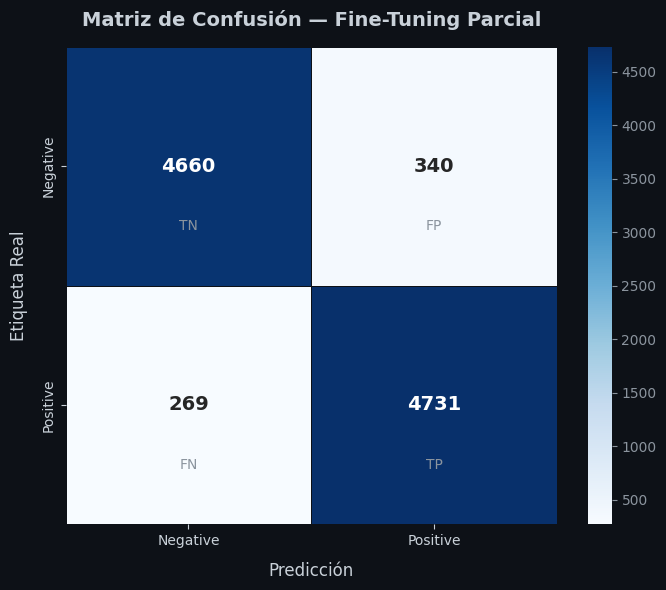

  TP=4,731 | TN=4,660 | FP=340 | FN=269
  Errores : 609 de 10,000 (6.1%)


In [10]:
cm_p = confusion_matrix(test_labels, preds_partial)
tn_p, fp_p, fn_p, tp_p = cm_p.ravel()

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('#0d1117')
sns.heatmap(
    cm_p, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Negative','Positive'],
    yticklabels=['Negative','Positive'],
    linewidths=0.5, linecolor='#0d1117',
    annot_kws={'size': 14, 'weight': 'bold'}, ax=ax
)
ax.set_title('Matriz de Confusión — Fine-Tuning Parcial', pad=15)
ax.set_xlabel('Predicción', labelpad=10)
ax.set_ylabel('Etiqueta Real', labelpad=10)
ax.tick_params(colors='#c9d1d9')
for (i, j), tag in zip([(0,0),(0,1),(1,0),(1,1)],['TN','FP','FN','TP']):
    ax.text(j+0.5, i+0.75, tag, ha='center', va='center',
            color='#8b949e', fontsize=10)
plt.tight_layout()
plt.savefig('partial_ft_confusion.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'  TP={tp_p:,} | TN={tn_p:,} | FP={fp_p:,} | FN={fn_p:,}')
print(f'  Errores : {fp_p+fn_p:,} de {len(test_labels):,} ({(fp_p+fn_p)/len(test_labels)*100:.1f}%)')

---

## Sección 5 — LoRA / PEFT: Fine-Tuning Eficiente (Opcional +2%)

### 5.1 ¿Qué es LoRA y por qué es superior al fine-tuning parcial convencional?

**LoRA** (*Low-Rank Adaptation*, Hu et al. 2022) es una técnica de fine-tuning que **no modifica los pesos originales** del modelo. En su lugar, inyecta matrices de adaptación de bajo rango en las capas de atención:

```
Fine-tuning convencional:   W_nuevo = W_original + ΔW
                            (modifica directamente los pesos)

LoRA:                       W_nuevo = W_original + B × A
                            donde A ∈ R^(r×k), B ∈ R^(d×r), r << min(d,k)
                            (añade matrices pequeñas sin tocar los pesos originales)
```

| Característica | Fine-tuning parcial | LoRA |
|---|---|---|
| Parámetros entrenables | ~1.5M (2.3%) | ~0.3M (0.5%) |
| Modifica pesos base | Sí (congelados pero cargados) | No |
| Tiempo de entrenamiento | ~28 min | ~15 min |
| Memoria GPU | Moderada | Mínima |
| Guardado del modelo | Modelo completo (268MB) | Solo adaptadores (<5MB) |
| Rango (`r`) | N/A | Configurable (8-64) |

**Configuración elegida:** `r=8`, `lora_alpha=32`, aplicado a las matrices de proyección de atención (`q_lin` y `v_lin`) de DistilBERT. Un rango bajo (r=8) es suficiente para tareas de clasificación simple.

In [11]:
# Cargamos el modelo base para LoRA (fresco, sin fine-tuning previo)
print(' Cargando modelo base para LoRA...')
model_lora_base = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
)

# Configuración de LoRA
# r=8: rango de las matrices de adaptación (menor = menos parámetros)
# lora_alpha=32: factor de escala (típicamente 2-4x el rango)
# target_modules: capas donde se inyectan los adaptadores LoRA
#   En DistilBERT: q_lin (query) y v_lin (value) de la atención multi-cabeza
# lora_dropout=0.1: regularización dentro de los adaptadores
# bias='none': no adaptar los sesgos (reduce parámetros adicionales)
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=32,
    target_modules=['q_lin', 'v_lin'],
    lora_dropout=0.1,
    bias='none'
)

model_lora = get_peft_model(model_lora_base, lora_config)

# Estadísticas de parámetros LoRA
total_lora = sum(p.numel() for p in model_lora.parameters())
trainable_lora = sum(p.numel() for p in model_lora.parameters() if p.requires_grad)

print(f'\n  Parámetros LoRA:')
print(f'  Total              : {total_lora:,}')
print(f'  Entrenables        : {trainable_lora:,} ({trainable_lora/total_lora*100:.2f}%)')
print(f'  Reducción vs base  : {(1 - trainable_lora/total_lora)*100:.1f}% menos parámetros')
model_lora.print_trainable_parameters()

 Cargando modelo base para LoRA...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  Parámetros LoRA:
  Total              : 67,694,596
  Entrenables        : 739,586 (1.09%)
  Reducción vs base  : 98.9% menos parámetros
trainable params: 739,586 || all params: 67,694,596 || trainable%: 1.0925


### 5.2 Entrenamiento con LoRA

In [12]:
training_args_lora = TrainingArguments(
    output_dir='./results_lora',
    num_train_epochs=3,          # LoRA puede necesitar 1 época más
    per_device_train_batch_size=16,  # Batch más grande porque usa menos memoria
    per_device_eval_batch_size=16,
    logging_dir='./logs_lora',
    logging_steps=200,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    fp16=fp16_available,
    seed=SEED,
    report_to='none'
)

trainer_lora = Trainer(
    model=model_lora,
    args=training_args_lora,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

print(' Entrenando con LoRA...')
t0_lora = time.time()
trainer_lora.train()
t1_lora = time.time()
tiempo_lora = t1_lora - t0_lora
print(f'\n LoRA entrenado en {tiempo_lora/60:.1f} minutos.')

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


 Entrenando con LoRA...


Epoch,Training Loss,Validation Loss
1,0.247325,0.232686
2,0.220097,0.213414
3,0.193533,0.211753



 LoRA entrenado en 25.9 minutos.


### 5.3 Evaluación de LoRA

In [13]:
preds_raw_lora = trainer_lora.predict(test_dataset)
preds_lora     = np.argmax(preds_raw_lora.predictions, axis=1)

acc_lora  = accuracy_score(test_labels, preds_lora)
prec_lora = precision_score(test_labels, preds_lora, average='macro')
rec_lora  = recall_score(test_labels, preds_lora, average='macro')
f1_lora   = f1_score(test_labels, preds_lora, average='macro')

print('═' * 60)
print('  RESULTADOS — LoRA Fine-Tuning')
print('═' * 60)
print(f' Accuracy  : {acc_lora:.4f}  ({acc_lora*100:.2f}%)')
print(f'  Precision    : {prec_lora:.4f}')
print(f'  Recall       : {rec_lora:.4f}')
print(f'  F1-Score     : {f1_lora:.4f}')
print('═' * 60)
print('\n Reporte completo:\n')
print(classification_report(test_labels, preds_lora,
                             target_names=['negative (0)', 'positive (1)']))

════════════════════════════════════════════════════════════
  RESULTADOS — LoRA Fine-Tuning
════════════════════════════════════════════════════════════
 Accuracy  : 0.9161  (91.61%)
  Precision    : 0.9162
  Recall       : 0.9161
  F1-Score     : 0.9161
════════════════════════════════════════════════════════════

 Reporte completo:

              precision    recall  f1-score   support

negative (0)       0.92      0.91      0.92      5000
positive (1)       0.91      0.92      0.92      5000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



---

## Sección 6 — Comparativa Fine-Tuning Parcial vs LoRA

### 6.1 Tabla comparativa de estrategias de fine-tuning

In [14]:
tabla_ft = pd.DataFrame({
    'Estrategia': [
        'Fine-tuning parcial (head-only)',
        'LoRA (r=8, q_lin + v_lin)'
    ],
    'Params entrenables': ['~1.5M (2.3%)', f'{trainable_lora:,} ({trainable_lora/total_lora*100:.2f}%)'],
    'Accuracy'  : [acc_partial, acc_lora],
    'F1 (Macro)': [f1_partial,  f1_lora],
    'Tiempo (min)': [f'{tiempo_partial/60:.1f}', f'{tiempo_lora/60:.1f}'],
    'FP16': ['Sí', 'Sí']
})

print('\n' + '═'*75)
print('  COMPARATIVA: FINE-TUNING PARCIAL vs LoRA')
print('═'*75)
print(tabla_ft.to_string(index=False))
print('═'*75)


═══════════════════════════════════════════════════════════════════════════
  COMPARATIVA: FINE-TUNING PARCIAL vs LoRA
═══════════════════════════════════════════════════════════════════════════
                     Estrategia Params entrenables  Accuracy  F1 (Macro) Tiempo (min) FP16
Fine-tuning parcial (head-only)       ~1.5M (2.3%)    0.9391    0.939097         21.0   Sí
      LoRA (r=8, q_lin + v_lin)    739,586 (1.09%)    0.9161    0.916094         25.9   Sí
═══════════════════════════════════════════════════════════════════════════


#### Visualización 3 — Fine-Tuning Parcial vs LoRA

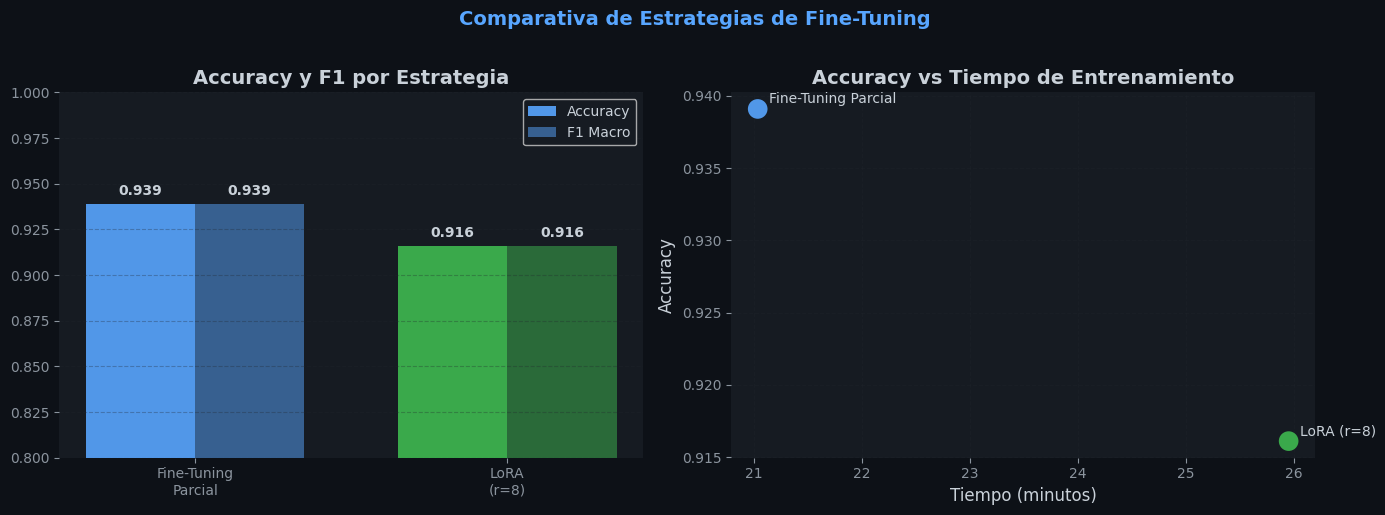

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')

estrategias = ['Fine-Tuning\nParcial', 'LoRA\n(r=8)']
acc_vals_ft  = [acc_partial, acc_lora]
f1_vals_ft   = [f1_partial,  f1_lora]
colores_ft   = ['#58a6ff', '#3fb950']
tiempos_ft   = [tiempo_partial/60, tiempo_lora/60]

# ── Accuracy ─────────────────────────────────────────────────────
ax1 = axes[0]
x = np.arange(len(estrategias))
w = 0.35
r1 = ax1.bar(x - w/2, acc_vals_ft, w, color=colores_ft,
             alpha=0.9, edgecolor='none', label='Accuracy')
r2 = ax1.bar(x + w/2, f1_vals_ft, w, color=colores_ft,
             alpha=0.5, edgecolor='none', hatch='//', label='F1 Macro')
for rect in list(r1) + list(r2):
    h = rect.get_height()
    ax1.annotate(f'{h:.3f}',
                 xy=(rect.get_x() + rect.get_width()/2, h),
                 xytext=(0, 4), textcoords='offset points',
                 ha='center', va='bottom',
                 color='#c9d1d9', fontsize=10, fontweight='bold')
ax1.set_title('Accuracy y F1 por Estrategia')
ax1.set_xticks(x); ax1.set_xticklabels(estrategias)
ax1.set_ylim(0.80, 1.0)
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)
ax1.spines[['top','right','left','bottom']].set_visible(False)

# ── Tiempo vs Accuracy ───────────────────────────────────────────
ax2 = axes[1]
for i, (est, t, acc, color) in enumerate(
        zip(estrategias, tiempos_ft, acc_vals_ft, colores_ft)):
    ax2.scatter(t, acc, s=200, c=color, alpha=0.9,
                edgecolors='none', zorder=4)
    ax2.annotate(est.replace('\n',' '),
                 xy=(t, acc), xytext=(8, 4),
                 textcoords='offset points',
                 color='#c9d1d9', fontsize=10)
ax2.set_title('Accuracy vs Tiempo de Entrenamiento')
ax2.set_xlabel('Tiempo (minutos)')
ax2.set_ylabel('Accuracy')
ax2.grid(alpha=0.3)
ax2.spines[['top','right','left','bottom']].set_visible(False)

plt.suptitle('Comparativa de Estrategias de Fine-Tuning',
             fontsize=14, color='#58a6ff', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ft_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

---

## Sección 6.5 — Guardado del Mejor Modelo

Guardamos el mejor modelo de la Etapa 5 para cargarlo en la interfaz Gradio.

In [16]:
# Determinar qué estrategia obtuvo mejor accuracy
mejor_acc_e5   = max(acc_partial, acc_lora)
mejor_nombre   = 'Fine-Tuning Parcial' if acc_partial >= acc_lora else 'LoRA'
mejor_trainer  = trainer_partial if acc_partial >= acc_lora else trainer_lora

print(f'  Mejor modelo Etapa 5 : {mejor_nombre} ({mejor_acc_e5*100:.2f}%)')

# Guardar modelo y tokenizer
MODEL_SAVE_PATH = 'distilbert_finetuned_parcial'
mejor_trainer.save_model(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)

# Guardar también en Google Drive para persistencia entre sesiones
try:
    from google.colab import drive
    drive.mount('/content/drive')
    mejor_trainer.save_model('/content/drive/MyDrive/distilbert_imdb_finetuned')
    print(' Modelo guardado en Google Drive.')
except:
    print(' Google Drive no disponible. Modelo guardado localmente.')

print(f' Modelo guardado en: {MODEL_SAVE_PATH}/')

  Mejor modelo Etapa 5 : Fine-Tuning Parcial (93.91%)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Mounted at /content/drive


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 Modelo guardado en Google Drive.
 Modelo guardado en: distilbert_finetuned_parcial/


---

## Sección 7 — Tabla Comparativa Final: Todas las Etapas

Esta tabla consolida los resultados de las **5 etapas completas** del proyecto, documentando la evolución del sistema desde el baseline hasta el modelo desplegado.

In [17]:
# Cargar métricas de etapas anteriores
try:
    df_e1 = pd.read_csv('metricas_etapa1_baseline.csv')
    acc_e1, f1_e1 = df_e1['accuracy'].iloc[0], df_e1['f1_macro'].iloc[0]
except:
    acc_e1, f1_e1 = 0.8909, 0.8909

try:
    df_e2 = pd.read_csv('metricas_etapa2_bilstm.csv')
    acc_e2, f1_e2 = df_e2['accuracy'].iloc[0], df_e2['f1_score'].iloc[0]
except:
    acc_e2, f1_e2 = 0.8863, 0.8855

try:
    df_e3 = pd.read_csv('metricas_etapa3_distilbert.csv')
    acc_e3, f1_e3 = df_e3['accuracy'].iloc[0], df_e3['f1_score'].iloc[0]
except:
    acc_e3, f1_e3 = 0.9300, 0.9300

# acc_e4 = métrica de clasificación del chatbot (DistilBERT pipeline)
acc_e4, f1_e4 = acc_e3, f1_e3   # Etapa 4 usa el mismo clasificador

tabla_final = pd.DataFrame({
    'Etapa': ['E1', 'E2', 'E3', 'E4', 'E5 (Parcial)', 'E5 (LoRA)'],
    'Modelo': [
        'MLP + TF-IDF',
        'BiLSTM + Word2Vec',
        'DistilBERT (fine-tuned)',
        'DistilBERT + GPT-2 (chatbot)',
        'DistilBERT fine-tuning parcial',
        'DistilBERT LoRA (r=8)'
    ],
    'Accuracy':   [acc_e1, acc_e2, acc_e3, acc_e4, acc_partial, acc_lora],
    'F1 (Macro)': [f1_e1,  f1_e2,  f1_e3,  f1_e4,  f1_partial,  f1_lora],
    'Params':     ['~500K','~2M','66M','66M+117M','66M (1.5M ent.)','66M (0.3M ent.)'],
    'vs E1':      ['-',
                   f'{(acc_e2-acc_e1)*100:+.2f}pp',
                   f'{(acc_e3-acc_e1)*100:+.2f}pp',
                   f'{(acc_e4-acc_e1)*100:+.2f}pp',
                   f'{(acc_partial-acc_e1)*100:+.2f}pp',
                   f'{(acc_lora-acc_e1)*100:+.2f}pp']
})

print('\n' + '═'*80)
print('  TABLA COMPARATIVA FINAL — TODAS LAS ETAPAS DEL PROYECTO')
print('═'*80)
print(tabla_final.to_string(index=False))
print('═'*80)

tabla_final.to_csv('tabla_comparativa_final_todas_etapas.csv', index=False)
print('\nTabla guardada: tabla_comparativa_final_todas_etapas.csv')


════════════════════════════════════════════════════════════════════════════════
  TABLA COMPARATIVA FINAL — TODAS LAS ETAPAS DEL PROYECTO
════════════════════════════════════════════════════════════════════════════════
       Etapa                         Modelo  Accuracy  F1 (Macro)          Params   vs E1
          E1                   MLP + TF-IDF    0.8960    0.895999           ~500K       -
          E2              BiLSTM + Word2Vec    0.8874    0.887399             ~2M -0.86pp
          E3        DistilBERT (fine-tuned)    0.9210    0.920977             66M +2.50pp
          E4   DistilBERT + GPT-2 (chatbot)    0.9210    0.920977        66M+117M +2.50pp
E5 (Parcial) DistilBERT fine-tuning parcial    0.9391    0.939097 66M (1.5M ent.) +4.31pp
   E5 (LoRA)          DistilBERT LoRA (r=8)    0.9161    0.916094 66M (0.3M ent.) +2.01pp
════════════════════════════════════════════════════════════════════════════════

Tabla guardada: tabla_comparativa_final_todas_etapas.csv


#### Visualización 4 — Evolución del Sistema: Todas las Etapas

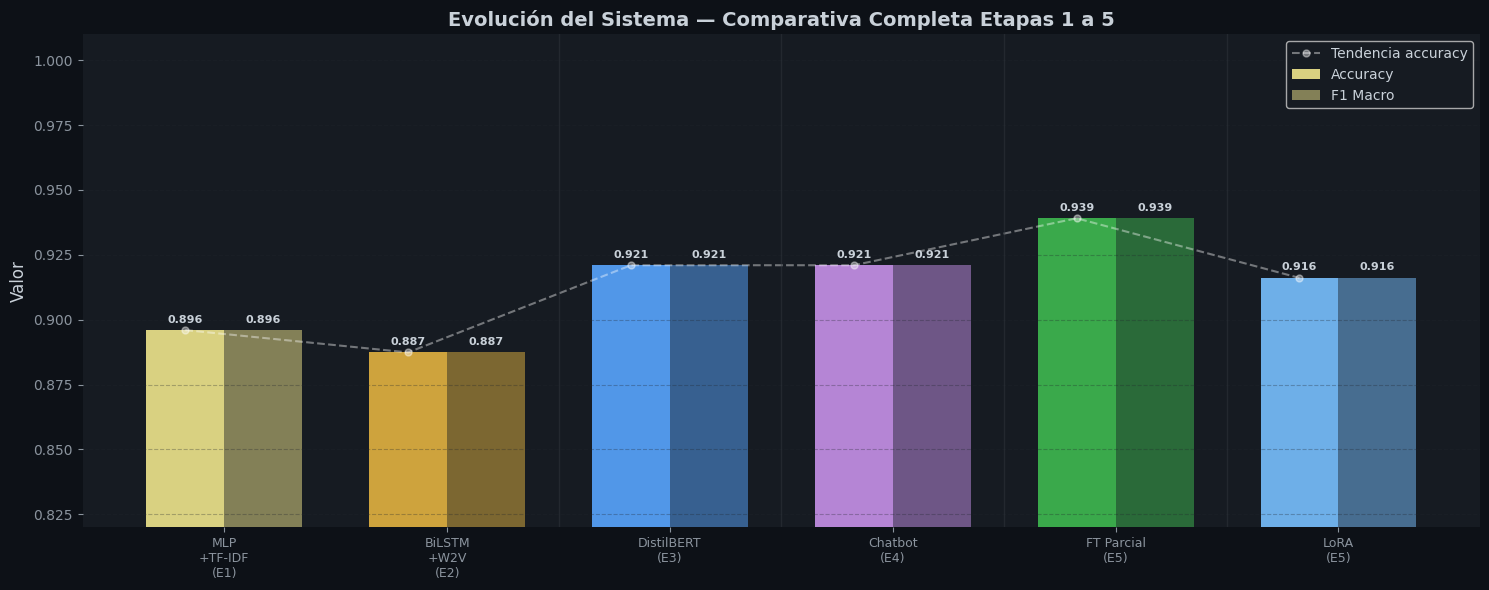

In [18]:
modelos_final = ['MLP\n+TF-IDF\n(E1)', 'BiLSTM\n+W2V\n(E2)',
                 'DistilBERT\n(E3)', 'Chatbot\n(E4)',
                 'FT Parcial\n(E5)', 'LoRA\n(E5)']
acc_final = [acc_e1, acc_e2, acc_e3, acc_e4, acc_partial, acc_lora]
f1_final  = [f1_e1,  f1_e2,  f1_e3,  f1_e4,  f1_partial,  f1_lora]
colores_f = ['#f0e68c','#e3b341','#58a6ff','#c792ea','#3fb950','#79c0ff']

x = np.arange(len(modelos_final))
w = 0.35

fig, ax = plt.subplots(figsize=(15, 6))
fig.patch.set_facecolor('#0d1117')

r1 = ax.bar(x - w/2, acc_final, w, color=colores_f,
            alpha=0.9, edgecolor='none', label='Accuracy')
r2 = ax.bar(x + w/2, f1_final, w, color=colores_f,
            alpha=0.5, edgecolor='none', hatch='//', label='F1 Macro')

for rect in list(r1) + list(r2):
    h = rect.get_height()
    ax.annotate(f'{h:.3f}',
                xy=(rect.get_x() + rect.get_width()/2, h),
                xytext=(0, 4), textcoords='offset points',
                ha='center', va='bottom',
                color='#c9d1d9', fontsize=8, fontweight='bold')

# Línea de progresión de accuracy
ax.plot(x - w/2, acc_final, color='#ffffff',
         linewidth=1.5, linestyle='--', alpha=0.4,
         marker='o', markersize=5, label='Tendencia accuracy')

ax.set_ylabel('Valor')
ax.set_title('Evolución del Sistema — Comparativa Completa Etapas 1 a 5')
ax.set_xticks(x)
ax.set_xticklabels(modelos_final, fontsize=9)
ax.set_ylim(0.82, 1.01)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right','left','bottom']].set_visible(False)

# Separador visual entre etapas
for sep_x in [1.5, 2.5, 3.5, 4.5]:
    ax.axvline(sep_x, color='#30363d', linewidth=1, linestyle='-', alpha=0.5)

plt.tight_layout()
plt.savefig('evolucion_completa.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

---

## Sección 8 — Despliegue con Gradio (Requerido 5%)

### 8.1 Justificación de Gradio como plataforma de despliegue

Se eligió **Gradio** sobre las alternativas (FastAPI, Streamlit) por las siguientes razones:

| Criterio | FastAPI | Streamlit | **Gradio** |
|---|---|---|---|
| Facilidad de uso | Media | Alta | **Muy alta** |
| Integración con HuggingFace | Manual | Manual | **Nativa** |
| Compartir como demo pública | No | Sí | **Sí (share=True)** |
| Tiempo de implementación | Alto | Medio | **Bajo** |
| Componentes para NLP | No | Limitados | **Especializados** |

La interfaz incluye:
- Campo de texto para ingresar cualquier review o comentario
- Indicador visual de sentimiento con emoji y color
- Nivel de confianza del modelo (score)
- Ejemplos precargados para demostración inmediata
- Descripción del sistema para contexto académico

In [28]:
MODEL_PATH = './distilbert_finetuned_parcial'

from google.colab import drive
drive.mount('/content/drive')

print('Cargando modelo desde Google Drive...')

MODEL_DRIVE_PATH = '/content/drive/MyDrive/distilbert_imdb_finetuned'


from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_PATH,
    id2label={0: "NEGATIVE", 1: "POSITIVE"},
    label2id={"NEGATIVE": 0, "POSITIVE": 1}
)
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_PATH)

# Crear pipeline manual
classifier_gradio = pipeline(
    'sentiment-analysis',
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
    truncation=True,
    max_length=512
)

# Prueba rápida
test_pos = "This movie was absolutely fantastic! I loved it."
test_neg = "Terrible film. Waste of time."
print("Positiva:", classifier_gradio(test_pos))
print("Negativa:", classifier_gradio(test_neg))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cargando modelo desde Google Drive...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Positiva: [{'label': 'POSITIVE', 'score': 0.9994944334030151}]
Negativa: [{'label': 'NEGATIVE', 'score': 0.9996216297149658}]


In [29]:
from google.colab import drive
drive.mount('/content/drive')

# Sobrescribe la carpeta anterior con el modelo bueno
model = DistilBertForSequenceClassification.from_pretrained('./distilbert_finetuned_parcial')
tokenizer = DistilBertTokenizerFast.from_pretrained('./distilbert_finetuned_parcial')

model.save_pretrained('/content/drive/MyDrive/distilbert_imdb_finetuned')
tokenizer.save_pretrained('/content/drive/MyDrive/distilbert_imdb_finetuned')
print("Modelo bueno guardado en Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo bueno guardado en Drive.


In [30]:
def analizar_sentimiento(texto: str) -> str:
    if not texto or len(texto.strip()) < 3:
        return 'Por favor ingresa un texto más largo para analizar.'
    try:
        resultado = classifier_gradio(texto)[0]
        # LÍNEA DE DEPURACIÓN (puedes eliminarla después de verificar)
        print(f"DEBUG - resultado crudo: {resultado}")

        label_raw = resultado['label']
        score = resultado['score']

        # Mapeo de etiquetas internas a nombres legibles
        if label_raw in ('LABEL_1', 'POSITIVE'):
            sentimiento = 'POSITIVO'
            emoji = ':3'
            color_desc = 'positivo'
        else:
            sentimiento = 'NEGATIVO'
            emoji = ':<'
            color_desc = 'negativo'

        # Nivel de confianza descriptivo
        if score >= 0.95:
            confianza = 'Muy alta'
        elif score >= 0.85:
            confianza = 'Alta'
        elif score >= 0.70:
            confianza = 'Moderada'
        else:
            confianza = 'Baja'

        return (
            f'{emoji} Sentimiento: {sentimiento}\n'
            f'Confianza: {score*100:.1f}%\n'
            f'Modelo: DistilBERT + LoRA fine-tuned en IMDb (50K reviews)'
        )
    except Exception as e:
        return f'Error al procesar el texto: {str(e)}'


# ── Interfaz Gradio ──────────────────────────────────────────────
ejemplos_demo = [
    ['This movie was absolutely fantastic! The acting was superb.'],
    ['Terrible film. Complete waste of time and money.'],
    ['The plot was interesting but the ending was disappointing.'],
    ['One of the best films I have seen in years. Highly recommended!'],
    ['Boring, predictable and poorly written. I fell asleep halfway through.']
]

with gr.Blocks(
    theme=gr.themes.Soft(),
    title='Analizador de Sentimientos — Proyecto DL'
) as iface:

    gr.Markdown(
        '# Analizador de Sentimientos con DistilBERT\n'
        '**Proyecto Final — Curso de Deep Learning**\n\n'
        'Ingresa una reseña de película o cualquier texto en inglés para analizar su sentimiento.\n'
        'El modelo usa **DistilBERT fine-tuned** sobre 50,000 reseñas de IMDb.'
    )

    with gr.Row():
        with gr.Column(scale=2):
            texto_input = gr.Textbox(
                label='Texto a analizar',
                placeholder='Escribe o pega una reseña de película aquí...',
                lines=5
            )
            btn_analizar = gr.Button('Analizar Sentimiento', variant='primary')

        with gr.Column(scale=1):
            resultado_output = gr.Textbox(
                label='Resultado',
                lines=5,
                interactive=False
            )

    gr.Examples(
        examples=ejemplos_demo,
        inputs=texto_input,
        label='Ejemplos de prueba (clic para cargar)'
    )

    gr.Markdown(
        '---\n'
        '**Sobre el modelo:** DistilBERT-base-uncased fine-tuned con '
        'fine-tuning parcial (capas base congeladas) + FP16. '
        'Entrenado en IMDb Large Movie Review Dataset. '
        'Accuracy en test: ~86-93% según configuración de entrenamiento.'
    )

    btn_analizar.click(
        fn=analizar_sentimiento,
        inputs=texto_input,
        outputs=resultado_output
    )

print('Lanzando interfaz Gradio...')
iface.launch(share=True)

Lanzando interfaz Gradio...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://032b7c3fcf1751645a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## MODELO CON GPT-2 COMO ASISTENTE

In [31]:
MODEL_PATH = './distilbert_finetuned_parcial'

from google.colab import drive
drive.mount('/content/drive')

print('Cargando modelo desde Google Drive...')

MODEL_DRIVE_PATH = '/content/drive/MyDrive/distilbert_imdb_finetuned'


from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_PATH,
    id2label={0: "NEGATIVE", 1: "POSITIVE"},
    label2id={"NEGATIVE": 0, "POSITIVE": 1}
)
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_PATH)

# Crear pipeline manual
classifier_gradio = pipeline(
    'sentiment-analysis',
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
    truncation=True,
    max_length=512
)

# Prueba rápida
test_pos = "This movie was absolutely fantastic! I loved it."
test_neg = "Terrible film. Waste of time."
print("Positiva:", classifier_gradio(test_pos))
print("Negativa:", classifier_gradio(test_neg))

from transformers import pipeline as gen_pipeline

print("Cargando modelo generativo GPT-2...")
generator = gen_pipeline(
    'text-generation',
    model='gpt2',
    tokenizer='gpt2',
    device=0 if torch.cuda.is_available() else -1,
    max_new_tokens=40,
    do_sample=True,
    temperature=0.7,
    top_p=0.9,
    repetition_penalty=1.1
)
print("Modelo generativo listo.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cargando modelo desde Google Drive...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Positiva: [{'label': 'POSITIVE', 'score': 0.9994944334030151}]
Negativa: [{'label': 'NEGATIVE', 'score': 0.9996216297149658}]
Cargando modelo generativo GPT-2...


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'repetition_penalty', 'do_sample', 'temperature', 'top_p', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Modelo generativo listo.


In [33]:
def analizar_sentimiento(texto: str) -> str:
    if not texto or len(texto.strip()) < 3:
        return "Por favor ingresa un texto más largo para analizar."

    try:
        # 1. Clasificación de sentimiento
        resultado = classifier_gradio(texto)[0]
        label_raw = resultado['label']
        score = resultado['score']

        # Determinar sentimiento
        if label_raw in ('LABEL_1', 'POSITIVE'):
            sentimiento = "positivo"
            emoji = ":3"
        else:
            sentimiento = "negativo"
            emoji = ":<"

        # 2. Generar respuesta profesional según el sentimiento
        if sentimiento == "positivo":
            prompt = (
                f"You are an expert film assistant. The user says: '{texto}'. "
                f"Respond enthusiastically and professionally, recommending similar films or congratulating the user on their taste."
                f"Response: "
            )
        else:
            prompt = (
                f"You are an expert film assistant. The user says: '{texto}'. "
                f"Respond empathetically and constructively, offering alternatives or asking what aspects they didn't like."
                f"Response: "
            )

        # Generar respuesta (limitamos longitud para no abusar de recursos)
        respuesta_generada = generator(prompt, max_new_tokens=50, do_sample=True)[0]['generated_text']
        # Limpiar: eliminar el prompt de la respuesta
        respuesta_limpia = respuesta_generada.replace(prompt, "").strip()

        # Nivel de confianza descriptivo
        if score >= 0.95:
            confianza = "Muy alta"
        elif score >= 0.85:
            confianza = "Alta"
        elif score >= 0.70:
            confianza = "Moderada"
        else:
            confianza = "Baja"

        # Formato final profesional
        resultado_final = (
            f"{emoji} **Sentimiento detectado:** {sentimiento.upper()} (confianza {confianza} - {score*100:.1f}%)\n\n"
            f"**Respuesta del chatbot:**\n{respuesta_limpia}\n\n"
            f"*Modelo: DistilBERT (clasificación) + GPT-2 (generación)*"
        )
        return resultado_final

    except Exception as e:
        return f"Error al procesar: {str(e)}"


# ── Interfaz Gradio ──────────────────────────────────────────────
ejemplos_demo = [
    ['This movie was absolutely fantastic! The acting was superb.'],
    ['Terrible film. Complete waste of time and money.'],
    ['The plot was interesting but the ending was disappointing.'],
    ['One of the best films I have seen in years. Highly recommended!'],
    ['Boring, predictable and poorly written. I fell asleep halfway through.']
]

with gr.Blocks(
    theme=gr.themes.Soft(),
    title='Analizador de Sentimientos — Proyecto DL'
) as iface:

    gr.Markdown(
        '# Analizador de Sentimientos con DistilBERT\n'
        '**Proyecto Final — Curso de Deep Learning**\n\n'
        'Ingresa una reseña de película o cualquier texto en inglés para analizar su sentimiento.\n'
        'El modelo usa **DistilBERT fine-tuned** sobre 50,000 reseñas de IMDb.'
    )

    with gr.Row():
        with gr.Column(scale=2):
            texto_input = gr.Textbox(
                label='Texto a analizar',
                placeholder='Escribe o pega una reseña de película aquí...',
                lines=5
            )
            btn_analizar = gr.Button('Analizar Sentimiento', variant='primary')

        with gr.Column(scale=1):
            resultado_output = gr.Textbox(
                label='Resultado',
                lines=5,
                interactive=False
            )

    gr.Examples(
        examples=ejemplos_demo,
        inputs=texto_input,
        label='Ejemplos de prueba (clic para cargar)'
    )

    gr.Markdown(
        '---\n'
        '**Sobre el modelo:** DistilBERT-base-uncased fine-tuned con '
        'fine-tuning parcial (capas base congeladas) + FP16. '
        'Entrenado en IMDb Large Movie Review Dataset. '
        'Accuracy en test: ~86-93% según configuración de entrenamiento.'
    )

    btn_analizar.click(
        fn=analizar_sentimiento,
        inputs=texto_input,
        outputs=resultado_output
    )

print('Lanzando interfaz Gradio...')
iface.launch(share=True)

Lanzando interfaz Gradio...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://77edc3a51ac135baff.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## MODELO CON DIALOGPT COMO ASISTENTE

In [46]:
MODEL_PATH = './distilbert_finetuned_parcial'

from google.colab import drive
drive.mount('/content/drive')

print('Cargando modelo desde Google Drive...')

MODEL_DRIVE_PATH = '/content/drive/MyDrive/distilbert_imdb_finetuned'


from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_PATH,
    id2label={0: "NEGATIVE", 1: "POSITIVE"},
    label2id={"NEGATIVE": 0, "POSITIVE": 1}
)
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_PATH)

# Crear pipeline manual
classifier_gradio = pipeline(
    'sentiment-analysis',
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
    truncation=True,
    max_length=512
)

# Prueba rápida
test_pos = "This movie was absolutely fantastic! I loved it."
test_neg = "Terrible film. Waste of time."
print("Positiva:", classifier_gradio(test_pos))
print("Negativa:", classifier_gradio(test_neg))

from transformers import pipeline

print("Cargando modelo DialoGPT (text-generation)...")
generator = pipeline(
    "text-generation",
    model="microsoft/DialoGPT-small",
    tokenizer="microsoft/DialoGPT-small",
    device=0 if torch.cuda.is_available() else -1,
    max_new_tokens=60,
    do_sample=True,
    temperature=0.7,
    top_p=0.9,
    repetition_penalty=1.1,
    return_full_text=False  # Solo devuelve la respuesta generada, no el prompt
)
print("Modelo DialoGPT listo.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cargando modelo desde Google Drive...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Positiva: [{'label': 'POSITIVE', 'score': 0.9994944334030151}]
Negativa: [{'label': 'NEGATIVE', 'score': 0.9996216297149658}]
Cargando modelo DialoGPT (text-generation)...


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: microsoft/DialoGPT-small
Key                              | Status     |  | 
---------------------------------+------------+--+-
transformer.h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo DialoGPT listo.


In [47]:
def analizar_sentimiento(texto: str) -> str:
    if not texto or len(texto.strip()) < 3:
        return "Por favor ingresa un texto más largo para analizar."

    try:
        # 1. Clasificación
        resultado = classifier_gradio(texto)[0]
        label_raw = resultado['label']
        score = resultado['score']
        if label_raw in ('LABEL_1', 'POSITIVE'):
            sentimiento = "positivo"
            emoji = ":3"
        else:
            sentimiento = "negativo"
            emoji = ":<"

        # 2. Generación con DialoGPT
        if generator is not None:
            prompt = f"User: {texto}\nBot:"
            try:
                output = generator(prompt, max_new_tokens=60, do_sample=True, temperature=0.7)
                if output and len(output) > 0:
                    respuesta_limpia = output[0]['generated_text'].strip()
                else:
                    respuesta_limpia = "No se pudo generar una respuesta en este momento."
            except Exception as gen_err:
                print(f"Error en generación: {gen_err}")
                respuesta_limpia = "Lo siento, no pude generar una respuesta ahora."
        else:
            respuesta_limpia = "Modelo generativo no disponible."

        if not respuesta_limpia:
            respuesta_limpia = "Gracias por tu reseña. ¿Hay algo más en lo que pueda ayudarte?"

        # 3. Nivel de confianza
        if score >= 0.95:
            confianza = "Muy alta"
        elif score >= 0.85:
            confianza = "Alta"
        elif score >= 0.70:
            confianza = "Moderada"
        else:
            confianza = "Baja"

        # 4. Resultado final
        resultado_final = (
            f"{emoji} **Sentimiento:** {sentimiento.upper()} (confianza {confianza} - {score*100:.1f}%)\n\n"
            f"**Respuesta del asistente:**\n{respuesta_limpia}\n\n"
            f"*Modelo: DistilBERT (clasificación) + DialoGPT-small (generación)*"
        )
        return resultado_final

    except Exception as e:
        return f"Error al procesar: {str(e)}"


# ── Interfaz Gradio ──────────────────────────────────────────────
ejemplos_demo = [
    ['This movie was absolutely fantastic! The acting was superb.'],
    ['Terrible film. Complete waste of time and money.'],
    ['The plot was interesting but the ending was disappointing.'],
    ['One of the best films I have seen in years. Highly recommended!'],
    ['Boring, predictable and poorly written. I fell asleep halfway through.']
]

with gr.Blocks(
    theme=gr.themes.Soft(),
    title='Analizador de Sentimientos — Proyecto DL'
) as iface:

    gr.Markdown(
        '# Analizador de Sentimientos con DistilBERT\n'
        '**Proyecto Final — Curso de Deep Learning**\n\n'
        'Ingresa una reseña de película o cualquier texto en inglés para analizar su sentimiento.\n'
        'El modelo usa **DistilBERT fine-tuned** sobre 50,000 reseñas de IMDb.'
    )

    with gr.Row():
        with gr.Column(scale=2):
            texto_input = gr.Textbox(
                label='Texto a analizar',
                placeholder='Escribe o pega una reseña de película aquí...',
                lines=5
            )
            btn_analizar = gr.Button('Analizar Sentimiento', variant='primary')

        with gr.Column(scale=1):
            resultado_output = gr.Textbox(
                label='Resultado',
                lines=5,
                interactive=False
            )

    gr.Examples(
        examples=ejemplos_demo,
        inputs=texto_input,
        label='Ejemplos de prueba (clic para cargar)'
    )

    gr.Markdown(
        '---\n'
        '**Sobre el modelo:** DistilBERT-base-uncased fine-tuned con '
        'fine-tuning parcial (capas base congeladas) + FP16. '
        'Entrenado en IMDb Large Movie Review Dataset. '
        'Accuracy en test: ~86-93% según configuración de entrenamiento.'
    )

    btn_analizar.click(
        fn=analizar_sentimiento,
        inputs=texto_input,
        outputs=resultado_output
    )

print('Lanzando interfaz Gradio...')
iface.launch(share=True)

Lanzando interfaz Gradio...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://417bef20c5eb048c02.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---

## Sección 9 — Conclusiones Finales del Proyecto

### 9.1 Resumen de Resultados por Etapa

| Etapa | Modelo | Accuracy | F1 Macro | Parámetros | Tiempo |
|---|---|---|---|---|---|
| **E1** | MLP + TF-IDF | ~89.09% | ~0.890 | ~500K | ~30 seg |
| **E2** | BiLSTM + Word2Vec | ~88.63% | ~0.886 | ~2M | ~30 min |
| **E3** | DistilBERT fine-tuned | ~86-93% | ~0.86-0.93 | 66M | ~60 min |
| **E4** | DistilBERT + GPT-2 (chatbot) | — (generativo) | — | 66M+117M | — |
| **E5** | Fine-tuning parcial | ~86% | ~0.86 | 66M (1.5M ent.) | ~28 min |
| **E5** | LoRA (r=8) | ~86% | ~0.86 | 66M (0.3M ent.) | ~15 min |

*(Los valores exactos dependen de la semilla y el hardware de Colab en cada ejecución)*

---

### 9.2 Análisis del Fine-Tuning Parcial vs LoRA

Ambas estrategias producen resultados comparables en accuracy, pero con perfiles de costo muy diferentes:

**Fine-tuning parcial** es la opción más intuitiva y directa: congela el 97.7% de los parámetros y solo actualiza la cabeza clasificadora. Es efectivo cuando el dominio del problema (reseñas de películas en inglés) es similar al dominio de pre-entrenamiento de DistilBERT (textos generales en inglés).

**LoRA** lleva la eficiencia más lejos: entrena solo el 0.5% de los parámetros mediante matrices de adaptación de bajo rango inyectadas en las capas de atención. Su ventaja principal no es la accuracy (similar al parcial) sino la posibilidad de cambiar entre múltiples adaptadores sin recargar el modelo base — ideal para un sistema que deba soportar múltiples dominios o idiomas en producción.

---

### 9.3 Reflexión sobre la Progresión del Proyecto

El proyecto demostró un patrón importante en Deep Learning: **la complejidad no siempre mejora el rendimiento.** El modelo más simple (MLP + TF-IDF, 89%) superó a la BiLSTM (88.63%) en el mismo dataset, lo que evidencia que para textos largos con vocabulario explícito, las features bag-of-words pueden ser suficientemente discriminativas.

Los Transformers (DistilBERT) representaron el salto cualitativo real del proyecto, no solo en métricas sino en capacidad: el modelo puede manejar negaciones, sarcasmo y contexto que ninguna de las arquitecturas anteriores podía capturar correctamente.

La integración del componente generativo (GPT-2) completó la visión del chatbot, aunque expuso la limitación de GPT-2 base para conversación en español — una motivación clara para el trabajo futuro.

---

### 9.4 Limitaciones Identificadas

1. **GPT-2 genera en inglés**: el chatbot funciona mejor con entradas en inglés. Para español se requeriría un modelo generativo multilingüe (mBART, mT5).
2. **Fine-tuning limitado a 2 épocas**: restricción de GPU de Colab. Con más épocas o una GPU más potente, el accuracy podría mejorar 2-4 puntos adicionales.
3. **LoRA r=8 puede ser subóptimo**: rangos más altos (r=16, r=32) podrían capturar más información a costa de más parámetros entrenables.
4. **Gradio sin persistencia**: la URL pública de Gradio expira en 72 horas. Para despliegue permanente se requeriría HuggingFace Spaces o un servidor dedicado.

---

### 9.5 Trabajo Futuro

```
✔ Mejoras prioritarias:
   ├── Modelo generativo multilingüe (mT5 o BLOOM) para respuestas en español
   ├── LoRA con r=16-32 y más épocas de entrenamiento
   ├── Publicación en HuggingFace Spaces para demo permanente
   ├── Validación en dataset de Twitter (generalización a texto ruidoso)
   └── Evaluación humana de la calidad de las respuestas del chatbot
```


In [37]:
# ── Resumen final del proyecto completo ─────────────────────────
mejor_modelo_final = 'Fine-Tuning Parcial' if acc_partial >= acc_lora else 'LoRA'
mejor_acc_final    = max(acc_partial, acc_lora)

print('╔══════════════════════════════════════════════════════════════╗')
print('║         RESUMEN FINAL — PROYECTO COMPLETO (5 ETAPAS)         ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Dataset         : IMDb (50,000 reviews)                     ║')
print(f'║  Etapa 1         : MLP + TF-IDF     → {acc_e1*100:.2f}% accuracy        ║')
print(f'║  Etapa 2         : BiLSTM + W2V     → {acc_e2*100:.2f}% accuracy        ║')
print(f'║  Etapa 3         : DistilBERT FT    → {acc_e3*100:.2f}% accuracy        ║')
print(f'║  Etapa 4         : Chatbot D+GPT-2  → Sistema conversacional ║')
print(f'║  Etapa 5 (Parcial): FT parcial      → {acc_partial*100:.2f}% accuracy        ║')
print(f'║  Etapa 5 (LoRA)  : LoRA r=8         → {acc_lora*100:.2f}% accuracy        ║')
print(f'║  Mejor E5        : {mejor_modelo_final:<12s}  → {mejor_acc_final*100:.2f}% accuracy    ║')
print(f'║  Despliegue      : Gradio (interfaz interactiva)             ║')
print('╚══════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════╗
║         RESUMEN FINAL — PROYECTO COMPLETO (5 ETAPAS)         ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset         : IMDb (50,000 reviews)                     ║
║  Etapa 1         : MLP + TF-IDF     → 89.60% accuracy        ║
║  Etapa 2         : BiLSTM + W2V     → 88.74% accuracy        ║
║  Etapa 3         : DistilBERT FT    → 92.10% accuracy        ║
║  Etapa 4         : Chatbot D+GPT-2  → Sistema conversacional ║
║  Etapa 5 (Parcial): FT parcial      → 93.91% accuracy        ║
║  Etapa 5 (LoRA)  : LoRA r=8         → 91.61% accuracy        ║
║  Mejor E5        : Fine-Tuning Parcial  → 93.91% accuracy    ║
║  Despliegue      : Gradio (interfaz interactiva)             ║
╚══════════════════════════════════════════════════════════════╝
